# Notebook 4 — Alfa y beta diversidad funcional

Usa `output_all_levels_and_function.csv` para calcular diversidad funcional alfa/beta, PCoA y pruebas diferenciales. Guarda figuras en `plots/`.

In [1]:
# Instalación de dependencias (ejecutar si es necesario)
# En Google Colab o un ambiente limpio, descomenta la siguiente línea:
!pip install pandas numpy scipy scikit-bio seaborn matplotlib statsmodels openpyxl xlrd scikit-learn

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

ALL_SAMPLES_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/all_samples.tsv"
METADATA_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/metadata_cibimi.csv"
FUNCTION_URL = "https://raw.githubusercontent.com/shadayguerrero/neonatal-gut-microbiome-analysis/refs/heads/main/data/output_all_levels_and_function.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def save_current_fig(filename, dpi=300):
    """Guarda la figura actual dentro de plots/ y la muestra."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura guardada en: {path}")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 46.9 MB/s eta 0:00:00


## 1. Carga y preparación de metadatos y funciones

In [2]:
def load_metadata(url=METADATA_URL):
    metadata = pd.read_csv(url).rename(columns={"MBI Sample ID": "SampleID"})
    metadata["SampleID"] = metadata["SampleID"].astype(str).str.strip()
    metadata = metadata.set_index("SampleID")
    if "Week" in metadata.columns:
        metadata["Week"] = pd.to_numeric(metadata["Week"], errors="coerce")
    if "Baby number" in metadata.columns:
        metadata["Baby number"] = metadata["Baby number"].astype(str)
    return metadata

def clean_sample_id(sample_name):
    return str(sample_name).split("_")[0].strip()

def load_function_table(url=FUNCTION_URL):
    func = pd.read_csv(url, sep=';') # Changed separator to semicolon

    # Diagnostic prints to inspect the loaded DataFrame
    print("--- func.head() ---")
    print(func.head())
    print("--- func.shape ---")
    print(func.shape)
    print("-------------------")

    # Assume the first column is the feature/function identifier
    feature_name = func.columns[0]

    numeric_cols = []
    annotation_cols = [feature_name] # The first column is always an annotation (feature name)

    # Iterate over the rest of the columns to find numeric ones
    print(f"Checking columns for numeric data in {url}...")
    for col_idx, col in enumerate(func.columns[1:]): # Start from the second column
        converted = pd.to_numeric(func[col], errors="coerce")
        mean_notna = converted.notna().mean()
        print(f"  Column '{col}' (index {col_idx+1}): % numeric = {mean_notna:.2f}")
        # A column is considered numeric if at least 10% can be converted to a number
        # (after coercing errors to NaN)
        if mean_notna >= 0.1: # Lowered threshold to 0.1
            numeric_cols.append(col)
        else:
            annotation_cols.append(col) # If not numeric enough, it's another annotation column

    if not numeric_cols:
        raise ValueError("No se detectaron columnas numéricas de abundancia funcional después de la primera columna de identificación, incluso con un umbral de detección más bajo.")

    func_counts = func.set_index(feature_name)[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).T
    func_counts.index = [clean_sample_id(i) for i in func_counts.index]
    func_counts = func_counts.groupby(func_counts.index).sum()
    func_counts = func_counts.loc[:, func_counts.sum(axis=0) > 0]
    func_rel = func_counts.div(func_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return func_counts, func_rel, func

metadata = load_metadata()
func_counts, func_rel, func_raw = load_function_table()
common = func_counts.index.intersection(metadata.index)
func_counts = func_counts.loc[common]
func_rel = func_rel.loc[common]
metadata = metadata.loc[common]

print(f"Muestras funcionales usadas: {func_counts.shape[0]}")
print(f"Funciones/features: {func_counts.shape[1]}")
func_counts.head()

--- func.head() ---
             Subsystem Level 1 Subsystem Level 2    Subsystem Level 3  \
0  Amino Acids and Derivatives                 -  Amino acid racemase   
1  Amino Acids and Derivatives                 -  Amino acid racemase   
2  Amino Acids and Derivatives                 -  Amino acid racemase   
3  Amino Acids and Derivatives                 -  Amino acid racemase   
4  Amino Acids and Derivatives                 -  Amino acid racemase   

                                            Function  \
0              2-methylaconitate_cis-trans_isomerase   
1  2-methylcitrate_dehydratase_(2-methyl-trans-ac...   
2  2-methylcitrate_dehydratase_FeS_dependent_(EC_...   
3            4-hydroxyproline_epimerase_(EC_5.1.1.8)   
4         4-oxalomesaconate_tautomerase_(EC_5.3.2.8)   

   S00SO-0033_S2251_R1.fastq  S00SO-0007_S1991_R1.fastq  \
0                        0.0                        0.0   
1                        0.0                        0.0   
2                        0.

Subsystem Level 1,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,Amino Acids and Derivatives,...,"Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense","Virulence, Disease and Defense"
S00SO-0001,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
S00SO-0002,0.0,0.0,0.0,0.0,0.0,19.011894,0.000000,0.333542,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
S00SO-0003,0.0,0.0,0.0,0.0,0.0,7.000890,0.000000,3.583789,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,1.000127,0.0,0.0,0.0,0.0
S00SO-0004,0.0,0.0,0.0,0.0,0.0,0.000000,0.866745,6.467248,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
S00SO-0005,0.0,0.0,0.0,0.0,0.0,10.667702,4.167071,13.868013,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000097,0.000000,0.0,0.0,0.0,0.0


## 2. Alfa diversidad funcional

In [3]:
from skbio.diversity import alpha_diversity

alpha_func = pd.DataFrame(index=func_counts.index)
alpha_func["shannon_funcional"] = alpha_diversity("shannon", func_counts.values, ids=func_counts.index)
alpha_func["simpson_funcional"] = alpha_diversity("simpson", func_counts.values, ids=func_counts.index)
alpha_func["funciones_observadas"] = alpha_diversity("observed_otus", func_counts.values, ids=func_counts.index)
alpha_func = alpha_func.join(metadata)
alpha_func.to_csv("alpha_diversidad_funcional.csv")
alpha_func.head()

/usr/local/lib/python3.12/dist-packages/skbio/util/_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,shannon_funcional,simpson_funcional,funciones_observadas,Your Sample ID,Baby number,Sampling Date,Weeks of gestation,Sample Type,Group,Sex,Weight,Size,Head Circunference,Abdominal Circunference,Necrotizing enterocolitis,Type of Birth,Clasification birth weight,Week
S00SO-0001,7.329233,0.998580,2279,C3.1,3,Week 1 (Birth),27.0,human feces,CONTROL,fem,800.0,34.0,24.0,18.0,No presence,Cesarean,Extremely low,1
S00SO-0002,6.353276,0.988795,4440,C3.2,3,Week 2,NaN,human feces,CONTROL,fem,805.0,34.0,23.0,18.0,No presence,Cesarean,Extremely low,2
S00SO-0003,8.253604,0.999548,8738,C3.3,3,Week 3,NaN,human feces,CONTROL,fem,870.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,3
S00SO-0004,8.235208,0.999544,9042,C3.4,3,Week 4,NaN,human feces,CONTROL,fem,910.0,34.0,24.0,20.0,No presence,Cesarean,Extremely low,4
S00SO-0005,8.348243,0.999590,10049,C3.5,3,Week 5,NaN,human feces,CONTROL,fem,NaN,NaN,NaN,NaN,No presence,Cesarean,Extremely low,5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Gráficas de alfa funcional

Figura guardada en: plots/funcional_alpha_shannon_funcional_por_group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


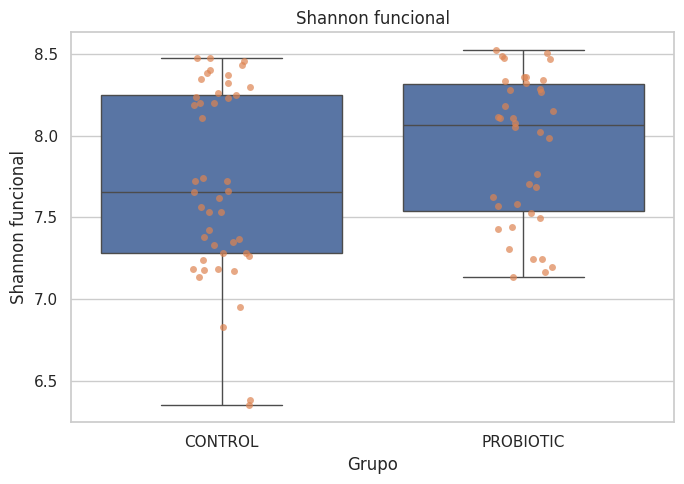

Figura guardada en: plots/funcional_alpha_simpson_funcional_por_group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


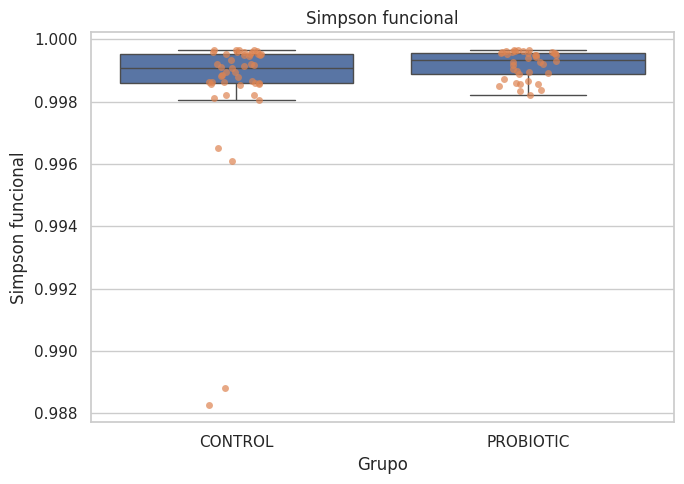

Figura guardada en: plots/funcional_alpha_funciones_observadas_por_group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


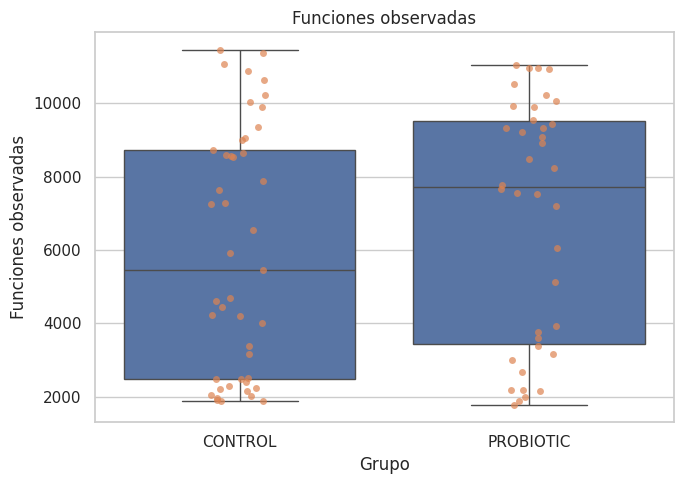

Figura guardada en: plots/funcional_alpha_shannon_funcional_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


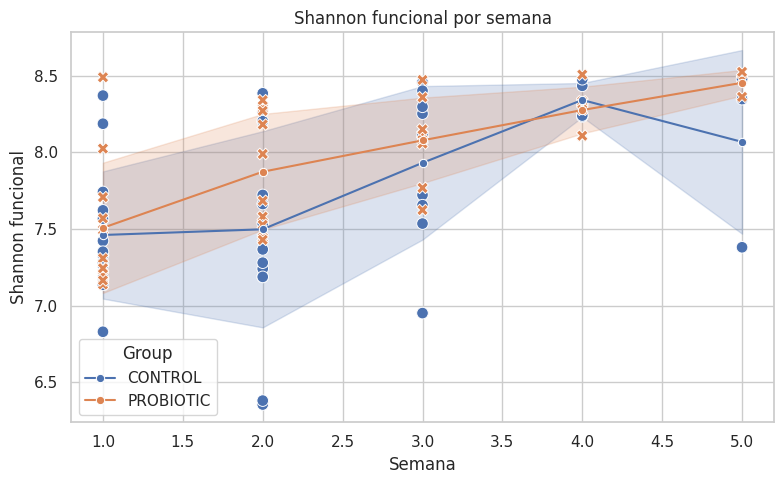

Figura guardada en: plots/funcional_alpha_simpson_funcional_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


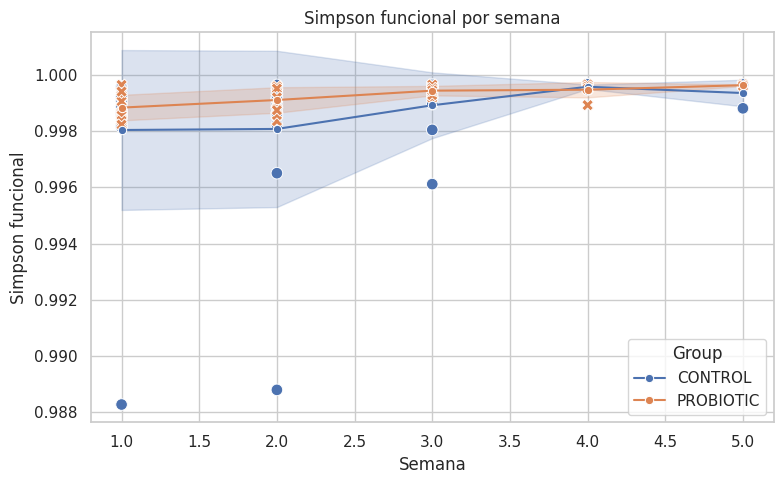

Figura guardada en: plots/funcional_alpha_funciones_observadas_por_semana.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


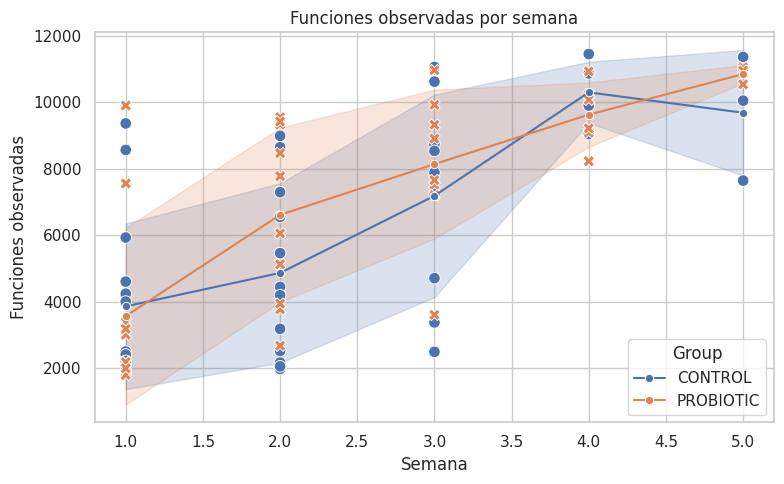

In [4]:
functional_metrics = {
    "shannon_funcional": "Shannon funcional",
    "simpson_funcional": "Simpson funcional",
    "funciones_observadas": "Funciones observadas"
}

for metric, label in functional_metrics.items():
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=alpha_func, x="Group", y=metric, showfliers=False)
    sns.stripplot(data=alpha_func, x="Group", y=metric, jitter=True, alpha=0.7)
    plt.title(label)
    plt.xlabel("Grupo")
    plt.ylabel(label)
    save_current_fig(f"funcional_alpha_{metric}_por_group.png")

if "Week" in alpha_func.columns:
    for metric, label in functional_metrics.items():
        plt.figure(figsize=(8, 5))
        sns.lineplot(data=alpha_func, x="Week", y=metric, hue="Group", estimator="mean", errorbar="sd", marker="o")
        sns.scatterplot(data=alpha_func, x="Week", y=metric, hue="Group", style="Group", s=70, legend=False)
        plt.title(f"{label} por semana")
        plt.xlabel("Semana")
        plt.ylabel(label)
        save_current_fig(f"funcional_alpha_{metric}_por_semana.png")

## 4. Beta diversidad funcional — Bray-Curtis y PCoA

Figura guardada en: plots/funcional_beta_pcoa_braycurtis_group.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


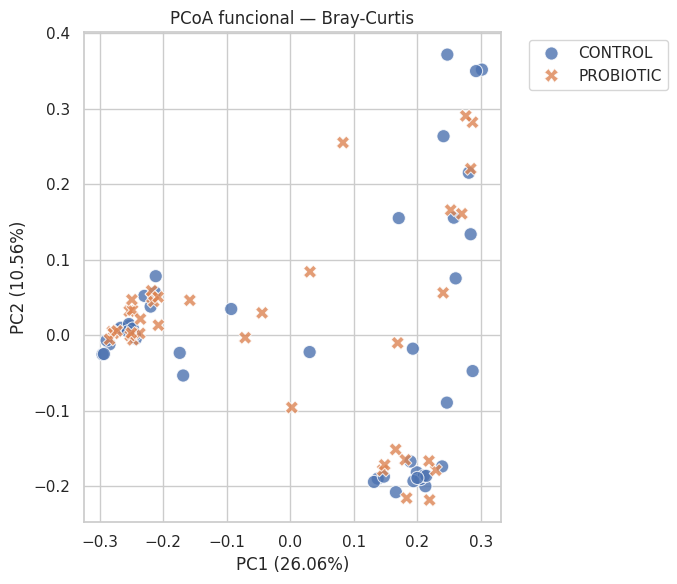

In [5]:
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

bray_func = beta_diversity("braycurtis", func_rel.values, ids=func_rel.index)
bray_func_df = bray_func.to_data_frame()
bray_func_df.to_csv("beta_funcional_braycurtis.csv")

pcoa_results = pcoa(bray_func)
pcoa_func_df = pcoa_results.samples.iloc[:, :2].join(metadata)
pcoa_func_df.to_csv("pcoa_funcional_braycurtis_scores.csv")

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pcoa_func_df, x="PC1", y="PC2", hue="Group", style="Group", s=90, alpha=0.8)
plt.xlabel(f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.2f}%)")
plt.title("PCoA funcional — Bray-Curtis")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
save_current_fig("funcional_beta_pcoa_braycurtis_group.png")

## 5. PERMANOVA funcional

In [6]:
from skbio.stats.distance import permanova

if "Group" in metadata.columns:
    print(permanova(bray_func, metadata["Group"], permutations=999))

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      83
number of groups                  2
test statistic             1.109907
p-value                       0.255
number of permutations          999
Name: PERMANOVA results, dtype: object


## 6. Funciones diferenciales por NEC

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

nec_col = "Necrotizing enterocolitis"
if nec_col in metadata.columns:
    data = func_rel.join(metadata[[nec_col]])
    print(data[nec_col].value_counts(dropna=False))
    groups = [g for g in data[nec_col].dropna().unique()]
    if len(groups) >= 2:
        group1, group2 = groups[0], groups[1]
        results = []
        for function in func_rel.columns:
            vals1 = data.loc[data[nec_col] == group1, function]
            vals2 = data.loc[data[nec_col] == group2, function]
            if len(vals1) > 1 and len(vals2) > 1:
                stat, pval = mannwhitneyu(vals1, vals2, alternative="two-sided")
                mean1, mean2 = vals1.mean(), vals2.mean()
                log2fc = np.log2((mean1 + 1e-9) / (mean2 + 1e-9))
                results.append([function, group1, group2, mean1, mean2, log2fc, pval])
        diff_func = pd.DataFrame(results, columns=["Function", "Group1", "Group2", "Mean_Group1", "Mean_Group2", "log2FC", "pvalue"])
        if not diff_func.empty:
            diff_func["qvalue"] = multipletests(diff_func["pvalue"], method="fdr_bh")[1]
            diff_func = diff_func.sort_values("qvalue")
            diff_func.to_csv("funciones_diferenciales_NEC.csv", index=False)
            display(diff_func.head(20))
else:
    print("No se encontró la columna Necrotizing enterocolitis.")

Necrotizing enterocolitis
No presence    77
IIB             6
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
